Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.
***

На этой теме мы завершаем _«базовый анализ»_ и после перейдем к работе с данными в машинном обучении (в каком-то виде). Поэтому это домашнее задание **подводит итог всем предыдущим** и добавляет красивую вишенку на тортике в виде динамической визуализации.

**Что это означает для вас?**  
Это означает, что при работе с данными ожидаются все те же шаги, что вы делали ранее, а именно
- [x] анализ проблем,
- [x] работа с пропусками,
- [x] работа с аномалиями,
- [x] нормальные текстовые выводы и объяснения проделанных махинаций.

Это не означает, что нужно нагромождать много кода. Это значит, что нужно уделить этому время и _**аккуратно, компактно отразить это в итоговой версии ноутбука**_. Если никаких проблем или махинаций нет, то об этом тоже нужно написать и _**объяснить, почему вы такие решения приняли**_.

# Введение и требования

Прежде чем перейти к заданиям, давайте разберёмся с теоретическими основами динамической визуализации и _**техническими требованиями к сдаче**_.

**Почему интерактивные графики лучше статических?**

Динамические графики позволяют быстро без дополнительного кода выбрать «ракурс» обзора данных:
- приближение,
- показ конкретного значения,
- фильтрация,
- сравнение.
  
Эти возможности позволяют делать анализ более понятным и быстрым для внешнего пользователя (вы как аналитик скорее всего будете кому-то представлять результаты аналитики, для этого и нужны нормальные текстовые выводы).

**Когда использовать динамическую визуализацию?**

Понятно, что для вас как для аналитика будет достаточно и обычных графиков, если вы научились их быстро и качественно делать, однако плюсы динамики именно в удобном представлении без глубокого погружения для взгляда со стороны.
* Дашборды для бизнес-пользователей
* EDA для представления вне
* Презентации с глубоким погружением
* Публикации в вебе

В этом задании мы (вы) поработаем с двумя библиотеками, позволяющими делать динамическую визуализацию: `plotly` и `bokeh`.  
Как всегда в задании будет теория, но вот ваша любимая полная документация по [плотли](https://plotly.com/python/plotly-express/?spm=a2ty_o01.29997173.0.0.3ef45171As9d36) и
[боке](https://docs.bokeh.org/en/latest/docs/user_guide.html?spm=a2ty_o01.29997173.0.0.2aa45171z7LipR).
***

# Данные

Как в прошлом задании тема была выбрана как что-то, что может быть полезным при работе аналитиком, так и тут мы затронем интересную тему. Будем работать с **временными рядами** — последовательностями данных, упорядоченных во времени. 

Для работы с этим заданием мы возьмем финансовые данные американского рынка в период `start='2021-01-01', end='2024-12-31'`. 
> Это не стандартный датасет, он специально подготовлен для задания.ли интересно,то он загружен с помощью [библиотеки](https://pypi.org/project/yfinance/) `yfinance` примерно следующими махинациями.
```python
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA', '^GSPC']
...
df_temp = stock.history(start='2021-01-01', end='2024-12-31')
...
df_temp = df_temp.rename(columns={
        'Open': 'Open',
        'High': 'High', 
        'Low': 'Low',
        'Close': 'Close',
        'Volume': 'Volume',
        'Date': 'Date'
    })
```

В дататасете есть 9 следующих **колонок**:
- `Date` — дата торговой сессии,
- `Open` — цена первой сделки дня,
- `High` — самая высокая цена за день,
- `Low` — самая низкая цена за день,
- `Close` — цена последней сделки,
- `Volume` — количество проданных акций,
- `Dividends` — выплаты дивидендов,
- `Stock Splits` — дробление/консолидация акций,
- `Ticker` — биржевой символ компании.

_Не сильно шарю в финансах, могла ошибиться, буду рада, если поправите._

Также, чтобы вы не искали приведу и **расшифровку тикеров**:
- `AAPL` — Apple Inc.,
- `GOOGL` — Alphabet Inc. то есть Google,
- `MSFT` — Microsoft Corporation,
- `AMZN` — Amazon.com  Inc.,
- `TSLA` — Tesla Inc.,
- `^GSPC` — S&P 500.

In [1]:
import pandas as pd

df = pd.read_csv('stocks_2021_2024.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2021-01-04 05:00:00,129.853846,129.941372,123.279459,125.856697,143301900,0.0,0.0,AAPL
1,2021-01-05 05:00:00,125.350958,128.122709,124.903582,127.412743,97664900,0.0,0.0,AAPL
2,2021-01-06 05:00:00,124.213113,127.451681,122.909903,123.123863,155088000,0.0,0.0,AAPL
3,2021-01-07 05:00:00,124.835528,128.015745,124.349256,127.325233,109578200,0.0,0.0,AAPL
4,2021-01-08 05:00:00,128.793735,128.988255,126.654145,128.424179,105158200,0.0,0.0,AAPL


In [2]:
df.Ticker.unique()

<StringArray>
['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA', '^GSPC']
Length: 6, dtype: str

In [3]:
# Проведите базовый анализ, чтобы познакомиться с данными
df.drop_duplicates()
df.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,6024,6024.000000,6024.000000,6024.000000,6024.000000,6.024000e+03,6024.000000,6024.000000
mean,2022-12-31 15:46:04.541832,919.956776,926.379614,913.267950,920.131667,7.554372e+08,0.002494,0.007138
min,2021-01-04 05:00:00,82.800003,83.480003,81.430000,81.820000,0.000000e+00,0.000000,0.000000
25%,2021-12-30 23:00:00,145.255585,146.839365,143.748695,145.336380,3.152960e+07,0.000000,0.000000
50%,2022-12-29 17:00:00,193.489027,196.240740,190.826438,193.275261,5.883660e+07,0.000000,0.000000
75%,2023-12-30 05:00:00,322.410289,325.413757,317.933854,321.669434,1.091818e+08,0.000000,0.000000
max,2024-12-30 05:00:00,6089.029785,6099.970215,6079.979980,6090.270020,9.976520e+09,0.830000,20.000000
std,NaN,1630.645618,1638.857632,1621.944737,1630.930251,1.602480e+09,0.036931,0.366425


Пропусков нет, везде 6024 значения, дубликатов нет тоже. Интересно, что в дате std - NaN. Хочется сделать дату индексом, к чему нам вообще стандартная индексация во временных рядах? Вернусь к этому вопросу позже, т.к. пока пытаюсь вникнуть в "физику дела". Хочется глянуть графички, чтобы понять, есть ли аномалии. Могут ли они вообще тут быть, если данные с рынка, то есть, автоматически валидные?

*И вот тут мне стало неочевидно, а как правильно выстроить работу дальше?... Да, мы уже работали с разными датасетами, должны понимать предобработку, одномерный и двумерный анализ, визуализацию, но я подумал: "блин, это же временные ряды рынка, у анализа подобных данных точно есть хороший проверенный пайплайн, надо найти". Нашёл следующую статью, попробую сделать по ней: https://habr.com/ru/companies/sberbank/articles/954636/* 

Выяснил, что на большинстве бирж торги только по будням. Надо проверить, что у нас так



In [4]:
df['Weekday'] = df['Date'].dt.dayofweek
print(df['Weekday'].unique())
df['Weekday'].value_counts()

[0 1 2 3 4]


Weekday
1    1242
2    1236
3    1218
4    1218
0    1110
Name: count, dtype: int64

Хорошо, у нас тоже торги только по будням. Но есть другая проблема: много будних дней пропущено, судя по всему, в связи с праздниками. Кажется, если я буду применять подход из статьи, то он не сработает, потому что будут сдвиги (один праздник, и понедельник уже стал вторником). В общем, пока мне всё совсем не очевидно.

*Думаю, это всё нужно будет делать дальше по ходу анализа, а сейчас требуются лишь базовые выводы. Их и сделаем*
- Датасет содержит 6024 записи по 6 тикерам. 
- Пропусков и дубликатов нет - это ожидаемо, потому что данные получены через yfinancе. 
- Данные охватывают только торговые дни (пн-пт), пропуски по праздникам = устройство биржи. Понедельников сильно меньше, потому что американские праздники обычно приходятся на понедельник
- Аномалий в ценах нет и быть не может - это достоверные рыночные данные, значение которых корректно по определению. Аномальные значения - события, которые важно учитывать, а не ошибки.
- Колонки дивидендов и консолидации почти всегда равны 0

Кажется, для первичного анализа этого достаточно, будем углубляться по ходу выполнения ДЗ.

# Задание 1: базовая визуализация (3 pt)

Прежде, чем приступить к визуалиции разберемся, что умеет базово делать `plotly`.

| Возможность | Параметр/метод | Что делает | Возможные значения |
| :---------- | :------------- | :--------- | :----------- |
| **Range Slider** | `.update_xaxes(rangeslider=)` | Ползунок для быстрого выбора периода | [это словарь с кучей параметров](https://plotly.com/python/reference/layout/xaxis/#layout-xaxis-rangeslider:~:text=the%20range%20selector.-,rangeslider,-Code%3A%20fig) |
| **Range Selector** | `.update_xaxes(rangeselector=)` | Кнопки для предопределённых периодов (1M, 3M, 1Y, All) | [это тоже словать с кучей параметров](https://plotly.com/python/reference/layout/xaxis/#layout-xaxis-rangeslider:~:text=to%20linear%20axes.-,rangeselector,-Code%3A%20fig) |
| **Hover** | `.update_layout(hovermode=)` | Точные значения при наведении курсора | [про hover в целом](https://plotly.com/python/hover-text-and-formatting/) |
| **Zoom/Pan** | Встроено по умолчанию | Детальное изучение любых участков графика | делается колесиком, перетаскиванием, кликом (где как) |
| **Export** | `fig.write_html()` / `fig.write_image()` | Сохранение графика как PNG/HTML | [про html](https://plotly.com/python/interactive-html-export/) |

Логика **основных компонентов `plotly figure`** примерно такая
```python
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 0. Создание фигуры
fig = go.Figure()
fig = make_subplots(...) # или так

# 1. Добавление данных (traces)
fig.add_trace(go.Candlestick(...))
fig.add_trace(go.Scatter(...))

# 2. Настройка layout
fig.update_layout(
    title="Заголовок",
    xaxis_rangeslider_visible=True,
    hovermode='x unified'
)

# 3. Сохранение
fig.write_html("output.html")
```

При этом каждая функция имеет огромное количество параметров, важно не перегрузить ими график.  
Пойдем по каждому из шагов.
***

#### Создание фигуры

Фигуру можно создать двумя способами:
* `fig = go.Figure()` — простая фигура (один график);
* `fig = make_subplots(...) — подграфики (несколько графиков в одном)`

В этой части мы сразу поработаем с **[подграфиками](https://plotly.com/python-api-reference/generated/plotly.subplots.make_subplots.html)**.

У этой функции следующие _основные_ параметры, поймите, какие для вас важны.

| Параметр | Тип | Что задает |
|:-------- | :-- | :--------- |
| `rows` | int | Количество рядов |
| `cols` | int | Количество колонок |
| `shared_xaxes` | bool | Общая ось X |
| `shared_yaxes` | bool | Общая ось Y |
| `vertical_spacing` | float | Отступ по вертикали |
| `horizontal_spacing` | float | Отступ по горизонтали |
| `row_heights` | list | Высота рядов (доли) |
| `column_widths` | list | Ширина колонок (доли) |
| `subplot_titles` | list | Заголовки подграфиков |

***

#### Добавление данных

Так как тут мы работаем с вполне конкретными финансовыми данными разберем 3 (4) **вида графиков**, которые нам могут пригодиться.

**[Свечной график](https://plotly.com/python/candlestick-charts/?spm=a2ty_o01.29997173.0.0.2aa45171z7LipR) (`Candlestick`)**  

Он нужен для отражения **изменения цены актива** за выбранный промежуток времени. Одна свеча показывает четыре ключевых ценовых показателя: цену открытия, закрытия, максимум и минимум.

Основные параметры у этого дела такие:
- `x` — даты/время,
- `open` — цена открытия,
- `high` — максимум дня,
- `low` — минимум дня,
- `close` — цена закрытия,
- `name` — название в легенде,
- `increasing_line_color` — цвет растущей свечи,
- `decreasing_line_color` — цвет падающей свечи,
- `hovertemplate` — шаблон подсказки при точечном рассмотрении.

**[Линейный график](https://plotly.com/python-api-reference/generated/plotly.graph_objects.Scatter.html) (`Scatter`)**

Привычный нам график, отрисовки линии можно добиться, меняя параметр `mode`.

- `x` — ось X,
- `y` — ось Y,
- `name` — название в легенде,
- `mode` — режим отображения (`'lines'`, `'markers'`, `'lines+markers'`),
- `line` — настройки линии,
- `marker` — настройки маркеров.

**[Столбчатый график](https://plotly.com/python-api-reference/generated/plotly.graph_objects.Bar.html) (`Bar`)**

Привычная нам столбчатая диаграмма с основными параметрами
- `x` — ось X,
- `y` — ось Y (значения),
- `name` — название в легенде,
- `marker_color` — цвет столбцов,
- `opacity` — прозрачность,
- `width` — ширина столбцов.

Добавление графиков на фигуру можно делать при [метода](https://plotly.com/python-api-reference/generated/generated/plotly.graph_objects.Figure.add_traces.html) `fig.add_trace()`.

***

#### Настройки графика

Настройка графиков производится разными методами, разберем основные из них

**Базовая настройка [layout](https://plotly.com/python/reference/layout/) `update_layout`**

С помощью этого метода делается базовая настройка внешнего вида графика. Параметров много, основные такие:
- `title` — заголовок графика,
- `height` — высота фигуры,
- `width` — ширина фигуры,
- `hovermode` — режим hover,
- `showlegend` — показывать ли легенду,
- `template` — тема оформления,
- `plot_bgcolor` — цвет фона графика,
- `margin` — отступы,
- `legend` — настройки легенды.

**[Настройка осей](https://plotly.com/python/reference/layout/xaxis/) (`update_xaxes`/`update_yaxes`)**

параметры для оси X `update_xaxes`:
- `rangeselector` — кнопки выбора периода,
- `rangeslider` — ползунок периода,
- `title` — название оси,
- `tickformat` — форма меток,
- `tickangle` — угол наклона меток,
- `row`, `col` — для **подграфиков**.

Для оси Y `update_yaxes` практически [аналогично](https://plotly.com/python/reference/layout/yaxis/).

**[Добавление аннотаций](https://plotly.com/python/text-and-annotations/) `add_annotation`**

иногда полезно добавлять на график какие-то метки, которые покажут дополнительную информацию, например информацию о внешних событиях (анонсы, торги, мировые события и т.д.)

```python
fig.add_annotation(
    x='2024-02-01',
    y=185.50,
    text='Чей-то отчет',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='green',
    ax=0,
    ay=-60,
    bgcolor='white',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=9),
    row=1,
    col=1
)
```

***

#### Сохранение

Ну и, наконец, после того, как вы все нарисовали нужно это **сохранить**.  

Метод `fig.show()` как и привычно отобразит график, но иногда это отображение может быть косячным (не влезать в ноутбук, не работают фичи в редакторе и все такое). Поэтому надо уметь **сохранять с сохранением интерактивности.**

Для этого существует метод `write_html`, который позволяет сохранить динамический формат и открыть его в браузере. Можно сильно не играться с параметрами, но на всякий случай вот они
- `file` — путь к файлу, в который сохранять,
- `include_plotlyjs` — встроить ли библиотеку,
- `full_html` — полный ли HTML документ,
- `config` — настройки,
- `auto_open` — открыть ли в браузере.
***

### Скользящее среднее

Это не пункт из создания графика, но важное знание при работе с временными рядами.  

**[Скользящее среднее (MA)](https://ru.wikipedia.org/wiki/%D0%A1%D0%BA%D0%BE%D0%BB%D1%8C%D0%B7%D1%8F%D1%89%D0%B0%D1%8F_%D1%81%D1%80%D0%B5%D0%B4%D0%BD%D1%8F%D1%8F)** — усреднение значений за определённый период, сдвигающийся во времени. Оно нужно для того, чтобы например отсматривать сигналы (для финансов), **определять тренд** как краткосрочный, так и долгосрочный.

**Простое скользящее среднее** считается так
$$SMA_t = \frac{1}{n} \sum\limits_{i=0}^{n-1} p_{t-1},$$
то есть как среднее по окну.

Скользящее среднее можно считать по разному, но мы в нашем задании ограничимся простым. Для подсчета его в пандасе как раз есть [штука](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) `.rolling`, которая вам поможет.

## Задание (3 pt)

В этом задании нужно сделать следующее и в качестве результата предъявить **интерактивный график** и **ВЫВОДЫ**, которые вы по нему сделали (они не обязаны быть большими, но должны быть емкими и нормально сформулированными).
1. Выберите **одну из компаний**, чьи активы хотите проанализировать (_это пойдет и во второе задание_).
2. Сделайте **подграфики**, связанные по оси X:
   * на верхнем отобразите **динамику цен** при помощи **свечного графика**,
   * на нижнем отобразите **динамику объема** при помощи **столбчатой диаграммы**.
3. Добавьте **ползунок выбора периода** снизу для грацика цен.
4. Добавьте **кнопки выбора периода** за 1 месяц, 3 месяца, 6 месяцев, год и все время.
5. Добавьте **hover** с деталями о значениях цен (открытия, закрытия, мин и макс) и объема.
6. Добавьте два **скользящих средних**: `MA-5` и `MA-20`.
7. Добавьте в качестве **аннотаций минимум 3 важных для рынка события** (дивиденды, отчеты, презентации новых продуктов или что-то подобное).

_Каждый пункт, кроме первого оценивается в 0,5 pt._  
Должно получиться что-то такое (события расположены абсолютно рандомно, я не гуглила)

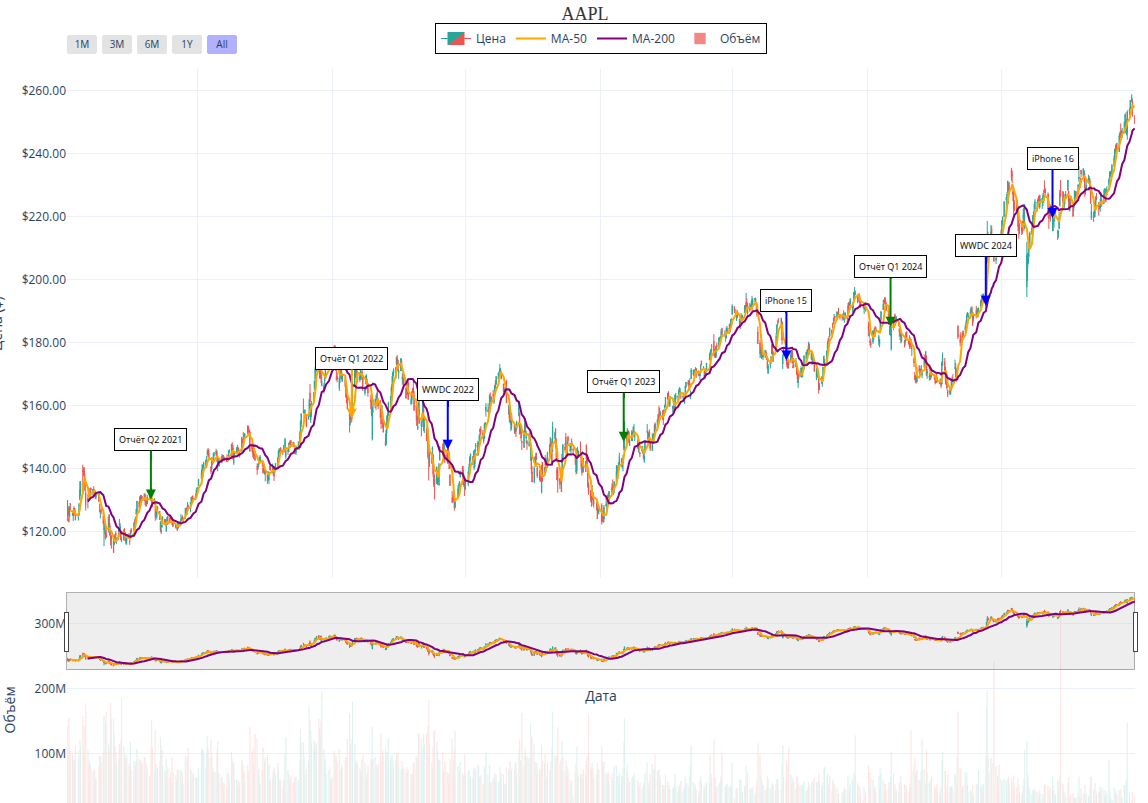  

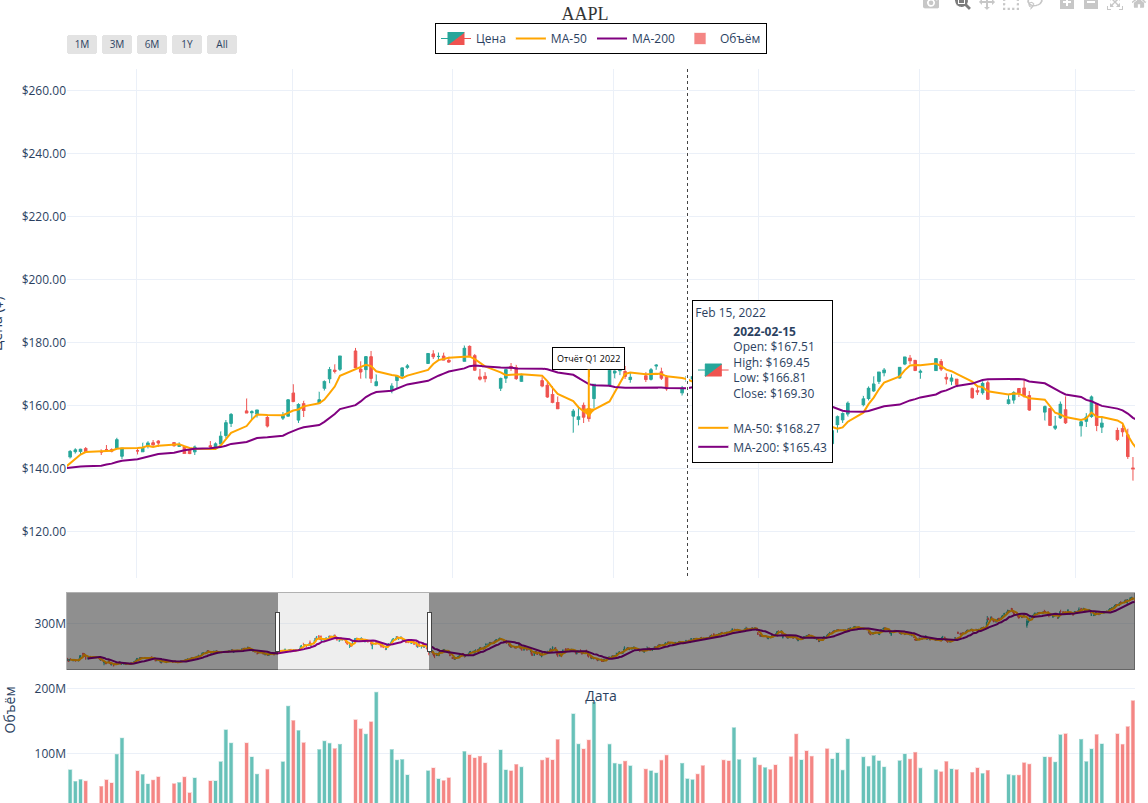 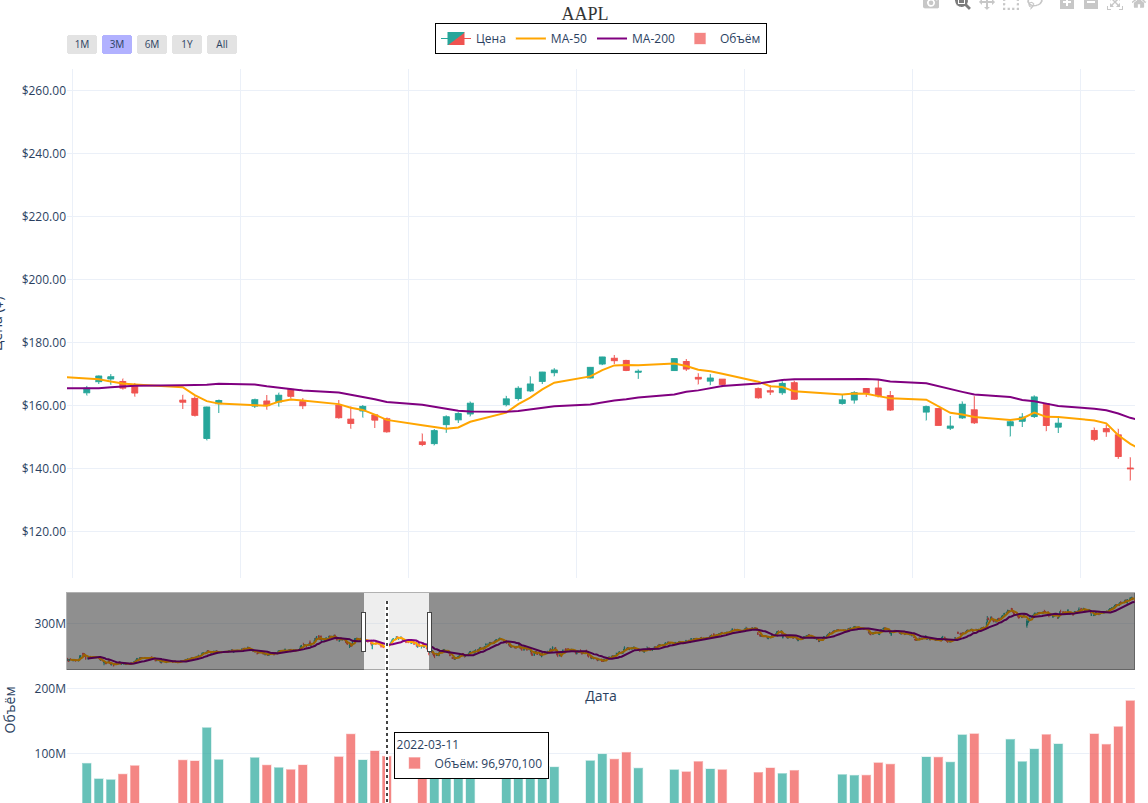

_Для удобства вам дан некоторый шаблон (то, как делала я), но вы можете менять его по своему усмотрению._

In [5]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

TICKER = "GOOGL" # Выберите одну компанию
df_stock = df[df['Ticker'] == TICKER].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

# Посчитайте скользящее среднее
df_stock['MA5'] = df_stock['Close'].rolling(5).mean() # Теперь понятно, почему 5 хотя-бы, потому что всего 5 торговых дней в неделе
df_stock['MA20'] = df_stock['Close'].rolling(20).mean()

# Задайте события, надо погуглить
EVENTS = [
    {"date": '2023-02-06', "text": "анонс Bard", "color": "green"},
    {"date": '2023-12-06', "text": "анонс Gemini", "color": "blue"},
    {"date": '2021-01-22', "text": "анонс закрытия Project Loon", "color": "red"},
]

annotated_events = []
for event in EVENTS:
    event_date = pd.to_datetime(event['date'])
    # Находим ближайшую торговую дату, вдруг ее нет в датасете
    closest_idx = (df_stock['Date'] - event_date).abs().idxmin()
    price_at_event = df_stock.loc[closest_idx, 'Close']
    event_date_actual = df_stock.loc[closest_idx, 'Date']
    
    annotated_events.append({
        'date': event_date_actual,
        'price': price_at_event,
        'text': event['text'],
        'color': event['color']
    })

In [6]:
fig = make_subplots(
    rows=2, 
    cols=1, 
    shared_xaxes=True,
)

# Добавление цен
fig.add_trace(
    go.Candlestick(
        x = df_stock['Date'],
        open = df_stock['Open'],
        high = df_stock['High'],
        low = df_stock['Low'],
        close = df_stock['Close'],
        name = 'Google'
    ),
    row=1, 
    col=1
)

# Добавление MA-5
fig.add_trace(
    go.Scatter(x = df_stock['Date'], y= df_stock['MA5'], mode='lines', name='MA5'),
    row=1, 
    col=1
)

# Добавление MA-20
fig.add_trace(
    go.Scatter(x = df_stock['Date'], y= df_stock['MA20'], mode='lines', name='MA20'),
    row=1, 
    col=1
)

# Добавление объема
fig.add_trace(
    go.Bar(x=df_stock['Date'], y=df_stock['Volume'], name='Volume'),
    row=2, 
    col=1
)

# Добавление событий
for event in annotated_events:
    fig.add_annotation(
        x=event['date'], 
        y=event['price'],
        text=event['text'],
        showarrow=False,
        font=dict(size=9),
        bgcolor='#444',
        bordercolor=event['color'],
        ax=0,
        ay=50,
        row=1, col = 1
    )


# Общая настройка вида
fig.update_layout(
    title="Google: цена и объём 2021-2024",
    height = 900,
    template="plotly_dark",
    hovermode='x unified',
    showlegend=False,
    margin=dict(l=50,r=50,t=60,b=50)
)

# Настройка Range Selector и range Slider
fig.update_xaxes(
    rangeselector=dict(
        bgcolor='#444',
        activecolor='red',
        y = 1,
        x = 0.75, #методом тыка подобрал, чтобы кнопки не накладывались с названием, выглядели красиво и имели удобное расположение
        buttons=list([
            dict(count=1, label="месяц", step="month", stepmode="backward"),
            dict(count=3, label="3 месяца", step="month", stepmode="backward"),
            dict(count=6, label="полгода", step="month", stepmode="backward"),
            dict(count=1, label="год", step="year", stepmode="backward"),
            dict(step="all")
        ]),
    ),
    rangeslider=dict(visible=True),
    tickformat="%Y-%m-%d",
    row=1, col=1
)

# Настройка оси X для графика объёма
fig.update_xaxes(
    tickformat="%Y-%m-%d",
    row=2,
    col=1
)

# Настройка осей Y
fig.update_yaxes(
    title_text="Цена в $",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Объём",
    row=2,
    col=1
)
# Сохранение
fig.write_html("visualizations/task_1.html", include_plotlyjs=True, full_html=True)
fig.show()

**НАПИШИТЕ ВЫВОДЫ ПОСЛЕ АНАЛИЗА ГРАФИКА**

За период 2021-2024 акция Google выросла примерно вдвое: с ~90 до ~180 долларов. При этом весь 2022 год было падение, от ~150 до ~80, после чего восстановилась и обновила исторический (за этот период) максимум. 

МА5 и МА20 сильно отличаются в периоды резких движений, что ожидаемо: MA5 быстрее реагирует на краткосрочные изменения, MA20 сглаживает их. Значительные расхождения видны в 2022 году во время падения

Всплекски объёма в начале февраля и в мае каждого года происходят примерно в даты публикации квартальных отчётов. Анонс Bard в феврале 2023 совпал с разочаровывающим отчетом, цена просела. Gemini в 2023 тоже заметного эффекта на цену не оказал. Либо я плохо подобрал события, либо это нормально для такой большой и старой компании, что её акции сильнее реагируют на финансовые отчёты, чем на проодуктовые анонсы.

# Задание 2: сезонность (2 pt)

#### Необходимая информация

**Сезонность** — это повторяющиеся паттерны во временном ряду, которые возникают через фиксированные промежутки времени. Само по себе слово общее, под ним могут понимать разное, поэтому давайте разделим.
***

* **Тренд** — долгосрочное направление движения значений.
* **Сезонность** — периодические колебания в определенное время (например перед праздниками). Может быть
  - _**дневная**_ (привязана к часам),
  - _**недельная**_ (призана к дням недели),
  - _**месячная**_ (может быть привязана к отчетному периоду или времени выплат),
  - _**годовая**_ (привязана к месяцам и важным событиям).
* **Цикл** — долгосрочные колебания без фиксированного периода
* **Остаток** — случайные колебания (шум).

Тогда значения во временном ряду можно **декомпозировать**, например, как сумму тренда, сезонности и остатка.

Мы не будем подробно разбирать декомпозицию, тут нам достаточно знать, что есть замечательная библиотека `statsmodels`, в которой реализованы методы, которые умеют выделять сезонность:
- [классическая](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) декомпозиция в `seasonal_decompose`,
- [более умная](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html) декомпозиция в `STL`.

```python
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['Close'],
    model='additive',    # 'additive' или 'multiplicative'
    period=251           # Количество торговых дней в году
)
```
***
В этом задании нам пригодятся еще один вид графиков `go.Heatmap()`.

**[Тепловая карта](https://plotly.github.io/plotly.py-docs/generated/plotly.graph_objects.Heatmap.html) `go.Heatmap()`**

```python
fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values,
    x=pivot_table.columns,
    y=pivot_table.index,
    colorscale='...',
    hovertemplate='Месяц: %{y}<br>День: %{x}<br>Доходность: %{z:.2f}'
))
```

## Задание (2 pt)

В этом пункте вам нужно сделать **два интерактивных графика и ВЫВОДЫ** по ним.
1. На первом графике отобразите **4 вида информации** (для каждой свой подграфик):
   * временной ряд _**цены закрытия**_,
   * **тренд** из разложения,
   * **сезонность** из разложения,
   * **остаток** разложения.
2. На втором графике отобразите **тепловую карту доходности по дням недели и месяцам**. То есть посчитайте, доходность в зависимости от месяца и дня недели в нем.
3. Для обоих графиков настройте парметры **zoom** и **hover**.

_Каждый график оценивается в 1 pt._  
Должно получиться что-то такое

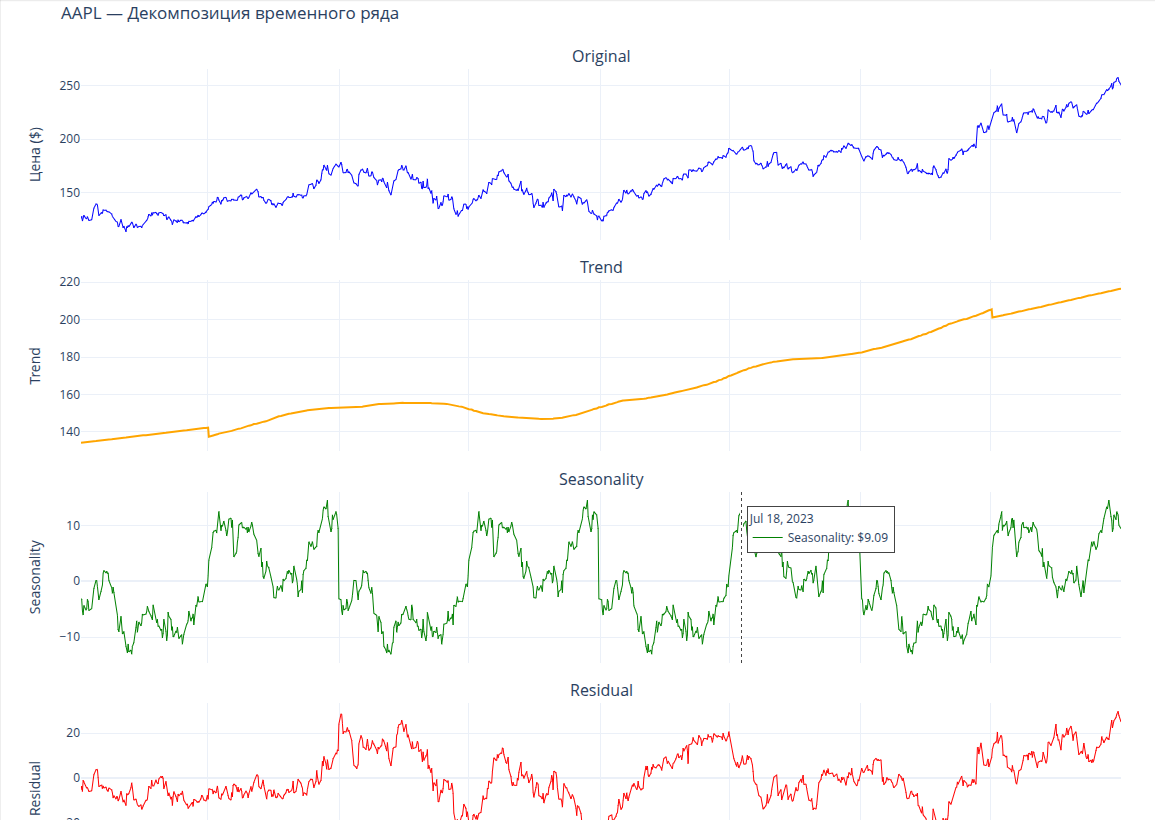  

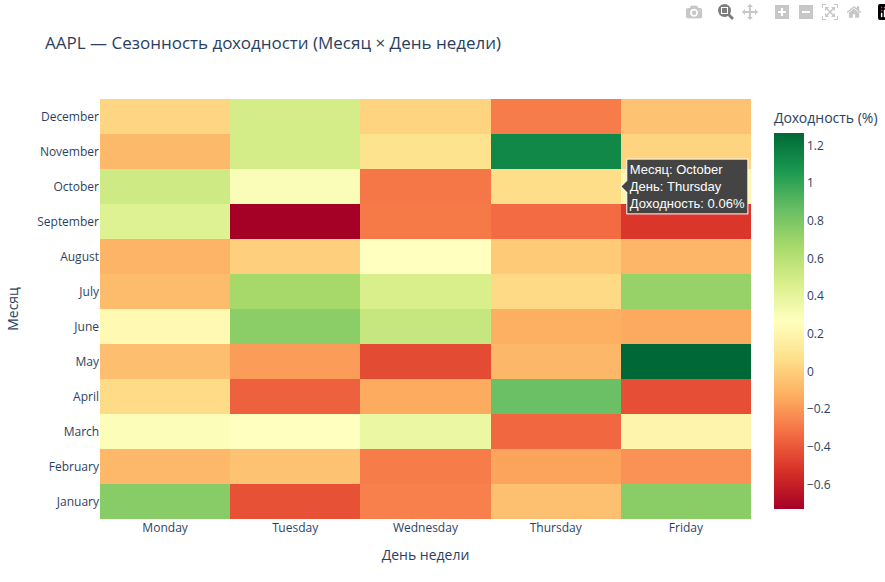

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_stock = df[df['Ticker'] == TICKER].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

# Выделите фичи
df_stock['Year'] = df_stock['Date'].dt.year
df_stock['Month'] = df_stock['Date'].dt.month
df_stock['MonthName'] = df_stock['Date'].dt.strftime('%B')
df_stock['DayOfWeek'] = df_stock['Weekday'] #уже делал прежде
df_stock = df_stock.drop(columns=['Weekday'])
df_stock['DayName'] = df_stock['Date'].dt.strftime('%A')
df_stock['WeekOfYear'] = df_stock['Date'].dt.isocalendar().week.astype(int)

# Процент доходности по сравнению с прошлым днем
df_stock['Return'] = df_stock['Close'].pct_change() * 100

# Используйте простой вариант
decomposition = seasonal_decompose(
    df_stock['Close'],
    model='additive',
    period = 252
)

# Извлечение компонентов
df_stock['Trend'] = decomposition.trend
df_stock['Seasonality'] = decomposition.seasonal
df_stock['Residual'] = decomposition.resid

In [8]:
# Создание фигуры с 4 подграфиками
fig = make_subplots(
    rows=4, 
    cols=1, 
    shared_xaxes=True, 
    subplot_titles=('Цена закрытия', 'Тренд', 'Сезонность', 'Остаток')
)

# Цена закрытия
fig.add_trace(go.Scatter(x=df_stock['Date'], y=df_stock['Close'], mode='lines', name='Цена закрытия', line=dict(color='steelblue')),row=1, col=1)

# Тренд
fig.add_trace(go.Scatter(x=df_stock['Date'], y=df_stock['Trend'], mode='lines', name='Тренд', line=dict(color='orange')), row=2, col=1)

# Сезонность
fig.add_trace(go.Scatter(x=df_stock['Date'], y=df_stock['Seasonality'], mode='lines', name='Сезонность', line=dict(color='green')), row=3, col=1)

# Остаток
fig.add_trace(go.Scatter(x=df_stock['Date'], y=df_stock['Residual'], mode='lines', name='Residual', line=dict(color='red')), row=4, col=1)

# Настройка layout
fig.update_layout(
    title=f"Декомпозиция ряда Google",
    height=900,
    template='plotly_dark',
    hovermode='x unified',
    showlegend=False
)

# Настройка осей
fig.update_xaxes(tickformat="%Y-%m-%d")
fig.update_yaxes(title_text="Цена ($)", row=1, col=1)
fig.update_yaxes(title_text="Тренд", row=2, col=1)
fig.update_yaxes(title_text="Сезонность", row=3, col=1)
fig.update_yaxes(title_text="Остаток", row=4, col=1)

fig.write_html("task_2_decomposition.html", include_plotlyjs=True, full_html=True)
fig.show()

In [9]:
# Подсчет средней доходности по месяцам и дням недели
pivot_table = df_stock.groupby(['MonthName', 'DayName'])['Return'].mean().unstack()

# Порядок месяцев и дней
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

pivot_table = pivot_table.reindex(index=month_order, columns=day_order)

# Создание heatmap
fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values,
    x=pivot_table.columns,
    y=pivot_table.index,
    colorscale = 'Hot'
))

# Настройка layout
fig.update_layout(
    title=f"Средняя дневная доходность Google по месяцам и дням недели",
    template='plotly_dark',
    height=500
)

fig.write_html("task_2_heatmap.html", include_plotlyjs=True, full_html=True)
fig.show()

#### Декомпозиция
- Тренд $\in [100,160], \Rightarrow $ разница в ~60 долларов за 4 года.
- Сезонность $\in [-10, 5], \Rightarrow$ ~10% от цены. Раз в год цена предсказуемо отклоняется примерно на 10% от тренда - вот и годовой сезонный паттерн. Период сезонности - один год соответственно.
- Остаток $\in [-10,10], \Rightarrow$ случайные события для Google влияют примерно так же, как и сезонность
Цену акций Google в основном объясняет тренд, а сезонность и случайные события добавляют примерно одинаковый шум по $\pm$ 10$. Предсказывать цену на основе сезонности сложно - остаток перекрывает

#### Тепловая карта
Явной недельной сезонности нет: нельзя сказать, что какой-то день недели стабильно лучше или хуже. По месяцам картина чуть интереснее: май и ноябрь чаще показывают положительную доходность, август близок к нулю. Однако разброс внутри каждой ячейки большой, поэтому это скорее наблюдение, чем закономерность.

# Задание 3: категории и связанные фильтры (4 pt)

#### Необходимая информация

В предыдущих заданиях вы делали анализ только для одной компании, немного грустно, правда? Давайте в этом задании поработаем именно над отображением и сравнением **всех компаний**.

Не трудно догадаться, что фича «тикер» является **категориальной**, и мы можем это использовать в нашей визуализации.

Начнем немного издалека и поговорим про **cross-filtering**.  
**Cross-filtering** — это техника, при которой взаимодействие с одним графиком влияет на отображение других графиков.

**Типы связей между графиками**

* **Shared Axes** — общая ось X или Y (zoom на одном → zoom на другом),
* **Legend Toggle** — клик на легенде → показать/скрыть (включить/выключить тикер),
* **Brushing** — выделение области → фильтр других (выбрать период → обновить статистику),
* **Click Events** — клик на точке → действие (клик на акции → показать детали),
* **Dropdown** — выбор в меню → обновление (выбрать метрику → изменить график).

То есть вы можете сделать так, чтобы на графике можно было **выбирать, какие компании показывать**: можно посмотреть все, можно отключить некоторые, можно оставить только одну. И более того, вы можете сделать так, чтобы выбор компании **влиял сразу на все подграфики** (обновлял масштаб, внешний вид, значения)!

Лучше идею этого можно посмотреть на картинках

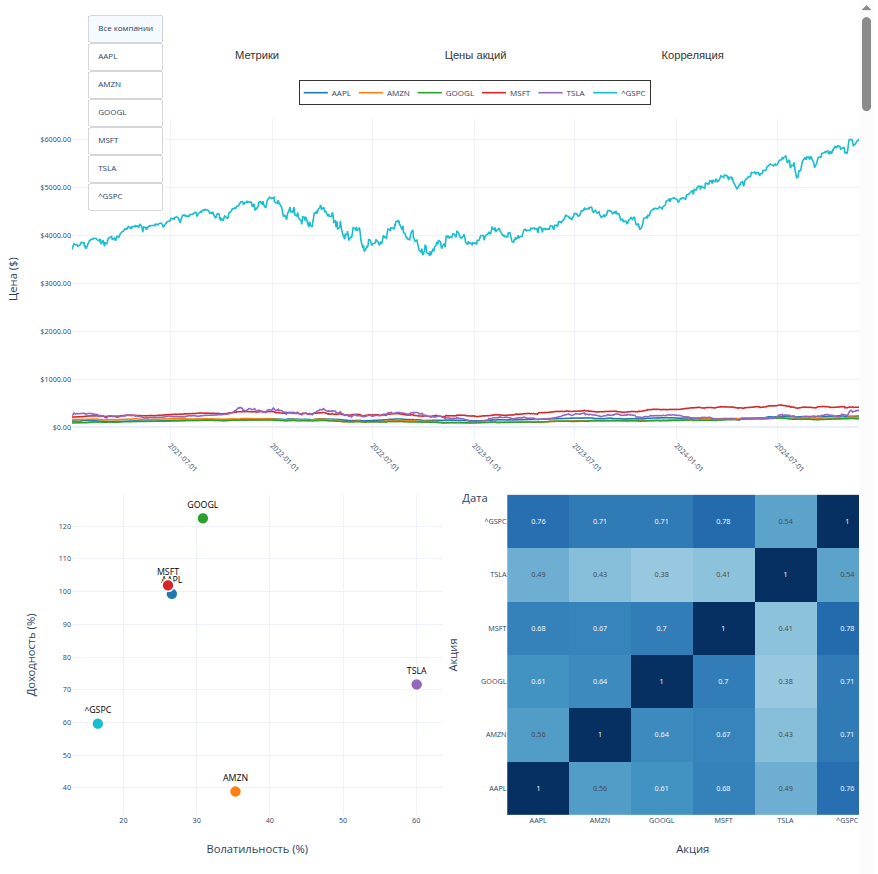 
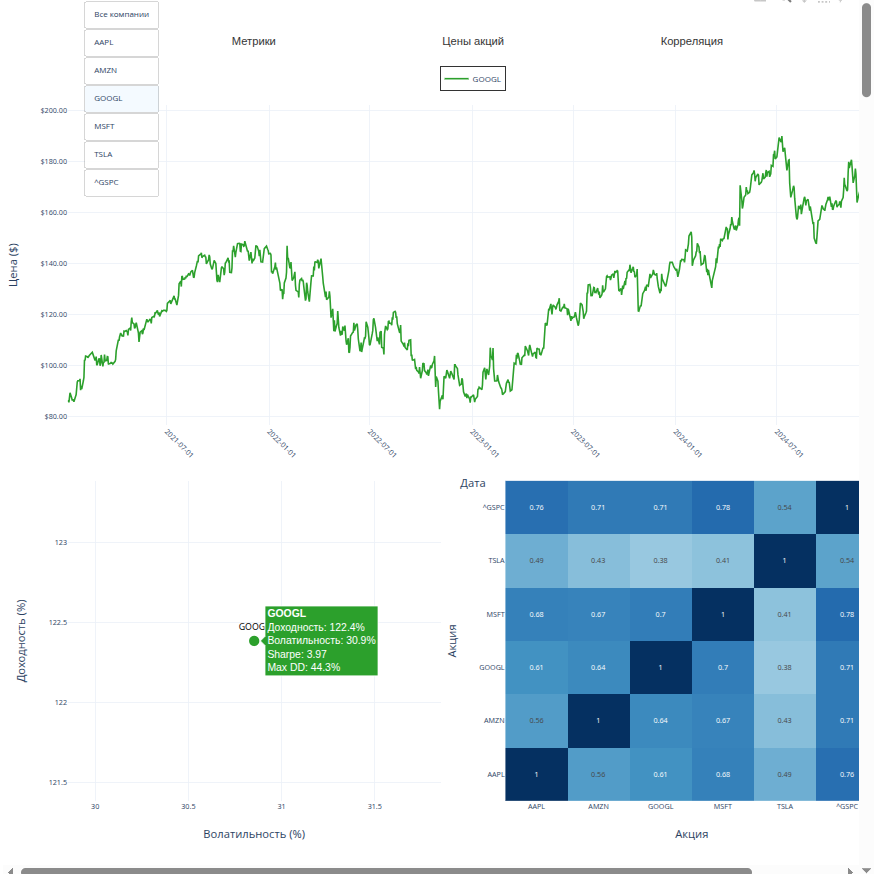

Подробнее можно почитать [тут](https://dash.plotly.com/interactive-graphing), я же оставлю те куски кода, которые вам могут понадобиться.

**Сложная сетка**

```python
fig = make_subplots(
    rows=2, 
    cols=2,
    shared_xaxes=False,
    shared_yaxes=False,
    specs=[[{"colspan": 2}, None],  # Row 1: 1 график на 2 колонки
           [{}, {}]]                # Row 2: 2 графика
)
```

**Обновление через меню**
```python
# Dropdown (updatemenus)
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(label="Цена", method="update", args=[...]), # тут можно передать visibility для отключения
                dict(label="Объём", method="update", args=[...])
            ])
        )
    ]
)
```

## Задание (4 pt)

Вам необходимо самостоятельно решить, какую именно информацию о компаниях вы хотите отобразить на графиках, и построить **несколько подграфиков на одной фигуре, связанных между собой**, а также сделать по ним **ВЫВОДЫ**.

Выбор фич полностью остается за вами, однако графики должны соответствовать следующим **трем критериям**:
* Должны быть **кнопки/фильтры выбора компаний**, которые влияют на отображение.
* Должно быть **минимум два связанных графика**, где изменение одного влияет на изменение другого.
* Должны быть минимум **три графика**, отображающие **разную информацию** (разные цены разной информацией не считаются).

Конечно, все это должно сопровождаться **легендой**, **названиями осей** и **hover**.

_Каждый пункт и выводы оцениваются в 1 pt._

Я решил, что мне интересны вот эти характеристики, по ним можно неплохо сравнить компании:
- нормализованная цена (кто вырос больше)
- волатильность (кто рискованнее)
- корреляция с SP500 - тикером, который отражает среднее движение 500 крупнейших американских компаний. По этой корреляции можно будет понять, кто следует рынку, а кто выбивается.

Всё остальное либо зашумлено, либо дублирует уже описанное, либо не додумался)

In [10]:
# Подготовка данных для всех тикеров кроме ^GSPC
tickers = [t for t in df['Ticker'].unique() if t != '^GSPC']
gspc = df[df['Ticker'] == '^GSPC'][['Date', 'Close']].rename(columns={'Close': 'GSPC'})

all_data = {}
for ticker in tickers:
    d = df[df['Ticker'] == ticker].copy().sort_values('Date').reset_index(drop=True)
    d['NormClose'] = d['Close'] / d['Close'].iloc[0] * 100 # старт = 100%
    d['Return'] = d['Close'].pct_change() * 100
    d['Volatility'] = d['Return'].rolling(21).std() # скользящая волатильность, окно ~месяц
    d = d.merge(gspc, on='Date')
    d['Correlation'] = d['Return'].rolling(60).corr(d['GSPC'].pct_change() * 100) # скользящая корреляция, окно ~квартал
    all_data[ticker] = d

# Цвета для компаний, просто на adobe color потыкал
COLORS = {
    'AAPL': '#a8d8ea',
    'GOOGL': '#f9ca24',
    'MSFT': '#6ab04c',
    'AMZN': '#e17055',
    'TSLA': '#fd79a8',
}

# 3 подграфика, общая ось X
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=(
        'Нормализованная цена (старт = 100)',
        'Волатильность (скользящее std доходности, окно 21 день)',
        'Скользящая корреляция с S&P 500 (окно 60 дней)'
    ),
    row_heights=[0.4, 0.3, 0.3]
)

for ticker in tickers:
    d = all_data[ticker]
    color = COLORS[ticker]

    # Нормализованная цена
    fig.add_trace(go.Scatter(
        x=d['Date'], y=d['NormClose'],
        mode='lines', name=ticker,
        line=dict(color=color, width=1.5),
        legendgroup=ticker,
        hovertemplate=f'{ticker}<br>Дата: %{{x|%Y-%m-%d}}<br>Норм. цена: %{{y:.1f}}'
    ), row=1, col=1)

    # Волатильность
    fig.add_trace(go.Scatter(
        x=d['Date'], y=d['Volatility'],
        mode='lines', name=ticker,
        line=dict(color=color, width=1.5),
        legendgroup=ticker,
        showlegend=False,
        hovertemplate=f'{ticker}<br>Дата: %{{x|%Y-%m-%d}}<br>Волатильность: %{{y:.2f}}%'
    ), row=2, col=1)

    # Корреляция с S&P 500
    fig.add_trace(go.Scatter(
        x=d['Date'], y=d['Correlation'],
        mode='lines', name=ticker,
        line=dict(color=color, width=1.5),
        legendgroup=ticker,
        showlegend=False,
        hovertemplate=f'{ticker}<br>Дата: %{{x|%Y-%m-%d}}<br>Корреляция: %{{y:.2f}}'
    ), row=3, col=1)


# Линия 100 на нормализованной цене для ориентира
fig.add_hline(y=100, row=1, col=1, line_dash='dot', line_color='gray', line_width=1)

fig.update_layout(
    title='Сравнение компаний: нормализованная цена, волатильность, корреляция с S&P 500',
    height=900,
    template='plotly_dark',
    hovermode='x unified',
    legend=dict(
        title='Компании',
        orientation='h',
        y=1,
        x=0.5,
        xanchor='center'
    ),
    margin=dict(l=60, r=40, t=80, b=50)
)

fig.update_xaxes(tickformat='%Y-%m-%d')
fig.update_yaxes(title_text='Цена (старт=100)', row=1, col=1)
fig.update_yaxes(title_text='Волатильность, %', row=2, col=1)
fig.update_yaxes(title_text='Корреляция', row=3, col=1)

fig.write_html('visualizations/task_3.html', include_plotlyjs=True, full_html=True)
fig.show()


#### Выводы по графикам
1) Tesla меньше всего коррелирует с S&P 500 в сравнении с остальными. Можно сказать, она менее зависима от рынка, чем все остальные. Наибольшая корреляция - у Apple, иногда выше 0.9. Тем не менее, у всех компаний корреляция положительная, значит, влияние рынка есть всегда.
2) У Tesla волатильность сильно выше в сравнении с остальными компаниями (у Amazon максимальная волатильность за период - 4,5%, у Tesla - 6,75%)
3) Tesla и Amazon - компании, у которых нормализованная цена сильно падала (до 50% от старта в худший для рынка период - конец 2022 и начало 2023). Это как раз объясняется высокой волатильностью этих компаний. Другие компании просто вернулись к цене, с которой начинали в 2021. Тем не менее, у Tesla в этом периоде корреляция с S&P 500 только 0.5, что означает, что у них были собственные причины падения.
4) Можно заметить, что у компаний есть общий тренд: в 2021 - рост, в 2022 - падение, 2023 и 2024 - снова рост, причём примерно теми же темпами. Это объясняется положительной корреляцией с S&P 500 у всех. 
5) Все компании выросли в нормированной цене к концу периода, но порядок роста разный. у Google +120% от старта, у Apple и Microsoft - +100%, у Tesla - +80%, у Amazon - +40%.

# Задание 4: дашборды в Bokeh (1+ pt)

В этом задании мы познакомимся с еще одной [библиотекой](https://docs.bokeh.org/en/latest/docs/user_guide.html?spm=a2ty_o01.29997173.0.0.2aa45171z7LipR) под названием `bokeh`. Эта библиотека позволяет делать **дашборды**, но **требует более детальной настройки** интерактивности (а также не позволяет работать на python без сервера со многими штуками, поэтому не пугайтесь js).

Мы не будем изучать все подробно, только попробуем построить простой график и сравним удобство работы с `plotly`. Если кратко, то базовый функционал следующий

| Функционал | Что делает | Метод |
| :--------- | :--------- | :---- |
| **figure()** | Создаёт холст для графика | `figure(title="...", x_axis_type="datetime")` |
| **Glyphs** | Создает геометрические примитивы | `line()`, `circle()`, `bar()`, `varea()` |
| **ColumnDataSource** | Создает источник данных для связывания графика | `ColumnDataSource(data=df)` |
| **Widgets** | Указывает интерактивные элементы | `Select()`, `Slider()`, `CheckboxGroup()` |
| **Callbacks** | Указывает реакцию на действия пользователя | `js_on_change()`, `on_change()` |
| **Layouts** | Делает компановку элементов | `column()`, `row()`, `gridplot()` |

Пока искала понятные гайды помимо документации нашла вот [это чудо](https://is42-2018.susu.ru/gaifulinakr/2020/05/15/quickstart-bokeh/), ахаах, просто смешняво.  
Ну а вообще [хабр](https://habr.com/ru/companies/otus/articles/755358/) помогает, очень мало, зато понятно.
***

Задание заключается в том, чтобы **дополнить код** для получения графика.

На графике должны быть отображены **цена закрытия** и **скользящее среднее** для акций одной компании. Должна присутствовать **возможность отключать графики**, должен быть **hover**.

Шаблон есть, пропуски довольно очевидны. если вы хотите поразбираться в библиотеке, то можете сделать _помимо этого_ более сложные графики (например повторить предыдущие задания) на дополнительные баллы.

In [11]:
from bokeh.plotting import figure, output_file, save
from bokeh.models import HoverTool
from bokeh.models import Select, ColumnDataSource, CustomJS
from bokeh.layouts import column

TICKER = "TSLA" #после предыдущего задания Тесла мне показалась наиболее интересной

# Срез по последним дням и подсчет скользящего среднего
def prepare_data(ticker, days=252):
    df_ticker = df[df['Ticker'] == ticker].copy()
    df_ticker = df_ticker.sort_values('Date').tail(days) 
    df_ticker['MA20'] = df_ticker['Close'].rolling(20).mean()
    return df_ticker

df_initial = prepare_data(TICKER)

source = ColumnDataSource(data=dict(
    Date=list(df_initial['Date'].dt.to_pydatetime()),
    Close=list(df_initial['Close']),
    MA20=list(df_initial['MA20']),
    Volume=list(df_initial['Volume']),
))

In [12]:
# Создание основной фигуры
p = figure(
    title=f"Tesla - Цена акции",
    x_axis_type="datetime",
    height=400,
    width=900,
    tools="pan,wheel_zoom,box_zoom,reset,hover", # интерактивные возможности
    toolbar_location="above" # место расположения виджетов
)

# Линия цены
p.line(
    x='Date', y='Close', # дата по x и цена по y
    source=source, 
    line_width=2, 
    color='steelblue',
    legend_label='Цена закрытия'
)

# Скользящее среднее
p.line(
    x='Date', y='MA20', 
    source=source, 
    line_width=1.5, 
    color='orange', 
    line_dash='dashed', # пунктир
    legend_label='MA20'
)

# Настройка hover
p.add_tools(HoverTool(
    tooltips=[ # шаблон отображение подсказки
        ("Дата", "@Date{%Y-%m-%d}"),
        ("Цена", "@Close{0.2f}"),
        ("MA20", "@MA20{0.2f}"),
    ],
    formatters={'@Date': 'datetime'},
    mode='vline'
))

# Настройка legend и осей
p.legend.location = "top_left"
p.legend.click_policy = "hide"  # клик по легенде скрывает линию
p.xaxis.axis_label = "Дата"
p.yaxis.axis_label = "Цена в $"

# Dropdown для выбора тикера
ticker_select = Select(
    title="Компания",
    value=TICKER,
    options=list(df['Ticker'].unique()), # нужно выдать лист значений тикеров
    width=300
)

# Подготовка данных для всех тикеров (для статического HTML)
all_data = {}
for ticker in df['Ticker'].unique():
    df_ticker = prepare_data(ticker)
    all_data[ticker] = dict(
        Date=list(df_ticker['Date'].dt.to_pydatetime()),
        Close=list(df_ticker['Close']),
        MA20=list(df_ticker['MA20'].fillna(0)),  #Почему тут MA50, если считали MA20?? заменил.
        Volume=list(df_ticker['Volume'])
    )

# JavaScript callback для обновления данных, не разбирайтесь в этом
callback = CustomJS(args=dict(source=source, data=all_data, title_obj=p.title), code="""
    const ticker = cb_obj.value;
    const new_data = data[ticker];
    
    // Обновляем источник данных
    source.data = new_data;
    source.change.emit();
    
    // Обновляем заголовок
    title_obj.text = ticker + ' - Цена акции';
""")

# Привязка JS callback
ticker_select.js_on_change('value', callback) # попробуйте просто on_change

layout = column(
    ticker_select,  
    p,              
    sizing_mode='scale_width',
    margin=20
)

output_file("visualizations/task_4.html", title="Bokeh Dashboard T4")
save(layout)

'C:\\Users\\olegs\\PycharmProjects\\data_analysis\\hw_5\\visualizations\\task_4.html'

_Что удобнее: plotly или bokeh?_

Plotly мне показался куда удобнее:
- fig.show() работает прям в ноутбуке
- hover, legend, zoom - из коробки, легко и просто
- дефолтный стиль вполне красивый, dark вообще великолепно выглядит

bokeh просто для наших целей не совсем подходит, он же для интерактивных дэшбордов для серверов, а не для быстрого анализа. Для наших задач как по мне plotly по всем параметрам выигрывает, bokeh был бы оправдан, если б мы делали какой-нибудь продакшн-дэшборд.

# Бонус (3+ pt)

Раз уж на этом мы заканчиваем тему аналитической аналитики и переходим к работе с данными в МО, то можете попробовать самостоятельно сделать первый шаг в это дело.

***
**ЗАДАНИЕ: построить предсказательную модель для одной из цен актива любой компании (мин, макс, старт, закрытие), добиться MASE < 0.9**
***

В качестве способа подготовки данных можете использовать **скользящие окна**, в качестве теста брать последнюю неделю или несколько. Вы можете предсказывать как на 1 день, так и на более длительный промежуток.  
В качестве моделей разрешено использовать **только классические методы** (без нейронок!):
* линейную регрессию,
* деревянные модели,
* бустинги.

_**В ЭТОМ ЗАДАНИИ ТОЖЕ ЗАПРЕЩАЕТСЯ ПОЛЬЗОВАТЬСЯ БЯМ. ВСЕ, ЧТО ВЫ СДЕЛАТЕ ВЫ ДОЛЖНЫ ПОНЯТЬ САМОСТОЯТЕЛЬНО, НАЙТИ В ГАЙДАХ И ДОКУМЕНТАЦИИ**_

#### Немного рассуждений

Думаю, далеко ходить не буду, буду просто пытаться предсказать `Open_{t+1}` у `TSLA` с помощью разных моделек. Очевидно, что линейная регрессия будет работать плохо, но всё равно начнём с неё. Может, удастся нарожать достаточно фич, чтобы оно заработало. 

*Вообще, я делал тут очень много экспериментов, но некоторые из них после того, как я нашёл инфу, показались настолько глупыми, что ноутбук было решено почистить. В большинстве своём я даже ничего не читал, решил просто методом тыка пролететь* 

Ниже будут ячейки с итоговым кодом, к которому я пришёл

Мой результат - `MASE = 0.4399`. Пробую бороться за сотые-тысячные доли MASE, просто потому что интересно.

In [13]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform, uniform
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

In [14]:
#Переместил сюда ячейку с подсчётом MASE, просто чтобы ниже не мешалась
# в scikit-learn MASE судя по всему нет, так что написал самостоятельно
from sklearn.metrics import mean_absolute_error
def mase(y_true, y_pred, y_train):
    naive_pred_train = y_train[:-1]  
    naive_true_train = y_train[1:]    
    mae_naive_train = mean_absolute_error(naive_true_train, naive_pred_train)
    mae_model = mean_absolute_error(y_true, y_pred)
    return mae_model / mae_naive_train

Как и говорил, берём теслу, убираем лишние столбцы. Я решил не использовать другие компании, покалось, много информации это не принесёт (даже использование столбцов SP-500 не дало большого прироста в метрике)

В итоге было принято решение прогнозировать не именно `Open`, а доходность, и из неё уже восстанавливать `Open`. 
Во всех статьях делают именно так, судя по всему, из-за [этого](https://translated.turbopages.org/proxy_u/en-ru.ru.aec22286-69bc18d3-5cc1ad69-74722d776562/https/quant.stackexchange.com/questions/16481/why-do-we-usually-model-returns-and-not-prices)

Все фичи были нагуглены или просто взяты из головы. Их полезность (то, что их наличие улучшает метрику) было выявлено экспериментально.

Какие фичи в итоге использовал:
- `Return` - доходность за день, изменение close процентах. 
- `MA_5` - скользящее среднее (окно 5 дней)
- `Volatility_10` - кользящая волатильность (окно 10 дней)
- `Close_lag1` - лаг закрытия 

От каких великолепных фич пришлось отказаться:
- `MA_10` - скользящее среднее (окно 10 дней)
- `Volatility_20` - cкользящая волатильность (окно 20 дней)
- `DayRange` - разброс цены за день в соотношении с ценой закрытия
- `Gap` - разброс между ценами открытия текущего дня и закрытием предыдущего в соотношении с закрытием 
- различные фичи, связанные с `SP500`: пробовал разное, ничего метрику не улучшало
- лаги (изначально добавлял их очень много, в итоге все пришлось убрать (кроме одного для `Close` 


In [15]:
mo = df[df['Ticker'] == 'TSLA'].copy().set_index('Date')

# Убираю параметры, которые оказались неважными
mo = mo.drop(columns=['Stock Splits', 'Dividends', 'Ticker','Weekday'])

# создание фич
mo['Return'] = mo['Close'].pct_change()
mo['MA_5'] = mo['Open'].rolling(5).mean()
mo['Volatility_10'] = mo['Return'].rolling(10).std()
mo[f'Close_lag1'] = mo['Close'].shift()
#mo[f'Open_lag1'] = mo['Open'].shift()

mo['Target'] = mo['Open'].pct_change().shift(-1)   # прогнозируем доходность открытия следующего дня, вместо Open
mo = mo.dropna() # в лагах появляются Nan`ы, убираем эти колонки

#Разделение на train/test по времени, по стандарту - 70/30
train_size = int(len(mo) * 0.7)
train = mo.iloc[:train_size]
test = mo.iloc[train_size:]

features = [col for col in mo.columns if col != 'Target']
X_train = train[features]
y_train = train['Target']
X_test = test[features]
y_test = test['Target']

Фичи насоздавали, данные подготовили, но это было и прежде (до пары). дальше - новое: pipeline, standart scaler, подбор гиперпараметров, SGDRegressor вместо LinearRegression из коробки.


Кажется, я очень много времени вчера потратил впустую вчера. Если бы я нашёл [ЭТУ](https://habr.com/ru/companies/skillfactory/articles/842444/) статью раньше...

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(random_state=42, early_stopping=True, validation_fraction=0.1))
])

param_grid = {
    'sgd__alpha': [1e-6, 1e-5, 0.0001, 0.001, 0.01, 0.1],  # сила регуляризации
    'sgd__learning_rate': ['constant', 'adaptive'],        # стратегия шага
    'sgd__eta0': [0.0001, 0.001, 0.01, 0.1, 0.15],         # начальный шаг (используется при constant/adaptive)
    'sgd__loss': ['squared_error', 'huber'],               # функция потерь (huber устойчива к выбросам)
    'sgd__penalty': ['elasticnet'],                        # тип регуляризации
    'sgd__l1_ratio' : [0.1, 0.3, 0.5, 0.7, 1.0]
}

param_distributions = {
    'sgd__alpha': loguniform(1e-6, 1e-1),                # логарифмически равномерное от 10^-6 до 10^-1
    'sgd__learning_rate': ['constant', 'adaptive'],      # категориальный выбор
    'sgd__eta0': loguniform(1e-4, 1e-1),                 # начальный шаг тоже перебираем логарифмически
    'sgd__loss': ['squared_error', 'huber'],
    'sgd__penalty': ['l2', 'elasticnet'],
    'sgd__l1_ratio': uniform(0.1, 0.9)                   # для elasticnet, равномерное от 0.1 до 1.0
}

tscv = TimeSeriesSplit(n_splits=5)  # 5 сплитов с расширяющимся окном

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=250,                # количество случайных комбинаций (можно увеличить/уменьшить)
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42            # для воспроизводимости
)

random_search.fit(X_train, y_train)
grid_search.fit(X_train, y_train)

print("Лучшие параметры Grid:", grid_search.best_params_)
print("Лучшие параметры Randomized:", random_search.best_params_)
print("Лучший MAE Grid:", grid_search.best_score_)
print("Лучший MAE Randomized", random_search.best_score_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Fitting 5 folds for each of 600 candidates, totalling 3000 fits
Лучшие параметры Grid: {'sgd__alpha': 1e-06, 'sgd__eta0': 0.15, 'sgd__l1_ratio': 0.3, 'sgd__learning_rate': 'adaptive', 'sgd__loss': 'huber', 'sgd__penalty': 'elasticnet'}
Лучшие параметры Randomized: {'sgd__alpha': 1.0602000020918366e-05, 'sgd__eta0': 0.08016452055726857, 'sgd__l1_ratio': 0.7398572309530734, 'sgd__learning_rate': 'adaptive', 'sgd__loss': 'squared_error', 'sgd__penalty': 'elasticnet'}
Лучший MAE Grid: -0.0163293177339971
Лучший MAE Randomized -0.01671215827446658


Как так получается?? Я добавляю ещё один параметр, который подбирается GridSearch`ем, и после этого результат модели **ухудшается**. 
Вроде, метрика подходящая (снижать MAE = снижать MASE). 

MAE на тесте: 3.3304
MASE на тесте: 0.4414


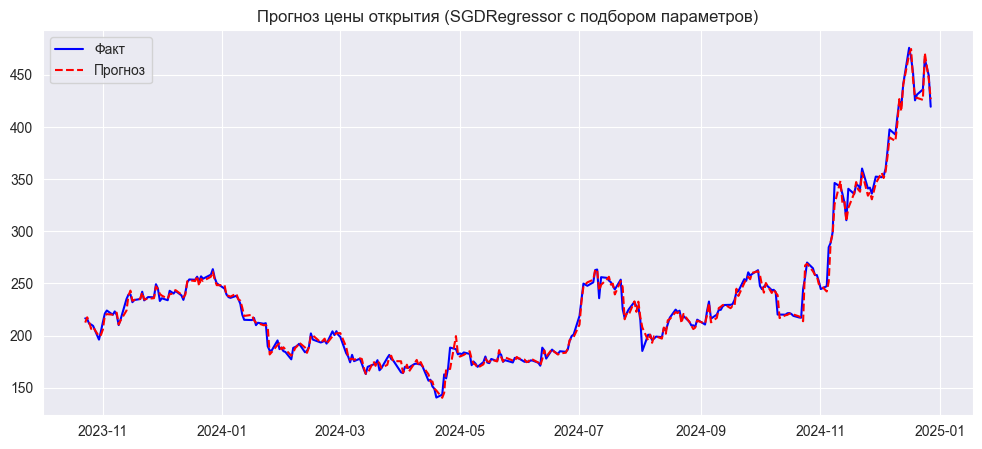

In [17]:
if grid_search.best_score_ > random_search.best_score_:
    best_model = grid_search.best_estimator_
else:
    best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Восстанавливаем цены для MASE и MAE
y_test_price = X_test['Open'] * (1 + y_test)
y_pred_price = X_test['Open'] * (1 + y_pred)
y_train_price = X_train['Open'] * (1 + y_train)

mae = mean_absolute_error(y_test_price, y_pred_price)
mase_val = mase(y_test_price.values, y_pred_price, y_train_price.values)

print(f"MAE на тесте: {mae:.4f}")
print(f"MASE на тесте: {mase_val:.4f}")

plt.figure(figsize=(12,5))
plt.plot(test.index, y_test_price, label='Факт', color='blue')
plt.plot(test.index, y_pred_price, label='Прогноз', color='red', linestyle='--')
plt.legend()
plt.title('Прогноз цены открытия (SGDRegressor с подбором параметров)')
plt.show()

Ниже идёт текстовая фиксация моих изысканий и ячейки, которые я использовал до того, как побывал на паре и решил всё переписать (тут нет ни standart scaler, ни pipeline, и гиперпараметры я не подбираю. Я игрался только с фичами, добавлением / убиранием столбцов)

#### Я избавил себя от нормальных данных и решил пострадать
Изначально я зачем-то убрал из данных вообще всё, кроме `Open` и `Volume` и попробовал предсказывать так. То, насколько сильно я ошибся, дошло до меня лишь спустя час. Пока предлагаю посмеяться над моими рассуждениями до осознания:

Первая гипотеза была создать 15 лагов и попробовать построить на них линейную регрессию. Получилось сильно грустно: `MASE = 0.9849`. 
Что интересно, после того, как я добавил return, MA5, MA10, MA20 и волатильность, ошибка возросла: `MASE = 0.9957`. 
А что если я теперь я сделаю 5 лагов, а не 15? `MASE = 0.9900`. Интересно. А если уберу другие фичи и сделаю 25 лагов? Получаю `MASE = 0.9890`

#### Прозрение
В общем, До тех пор, пока я не вернул `Close`, я не получал нормальный MASE. Очевидно, что цена закрытия помогла - она очень рядом с ценой открытия следующего дня. Как только добавил `Close_t`, MASE сразу стал `0.5811`. Но мне кажется, можно лучше.

-При конфигурации "по 2 лага для open, return, close" + волатильность SP500, я получил MASE `0.5738`. Кажется, слабое продвижение.
-Сделал так, что добавлял всех лагов (return, close, open) по 5 штук - получил `MASE = 0.5821`
- Добавил только по одному лагу - получил `MASE = 0.5677`
- Убрал признаки SP500 - получил `MASE = 0.5680`.
- Вернул `High` и `Low`, добавил `Gap` и `DayRange` - получил `MASE = 0.5412`
- Прошёлся StandartScale'ом на паре - получил `MASE = 0.4792`

#### Интересности
Если я поменяю тикера на `GOOGL`, то `MASE` у меня будет ужаснейший. Думаю, дело в том, что Tesla гораздо волатильнее, и поэтому наивный прогноз для неё не работает. Гугл же стабильнее, поэтому с ним было бы сложнее. Думаю, это также подтверждается тем, что на Amazon `MASE` между Tesla и Google - примерно 0.83. Кажется, я не подозревая того, считерил, взяв для метрики `MASE` Теслу. Хотя. и на Apple работает нормально... Удивительно, даже на GSPC `MASE` = 0.6529. На всех компаниях построенная мной штука укладывается в метрику, кроме Google.


#### Второй день, после пары АД

*И вот только я собирался добавлять пайплайн, standart scaler, подбирать гиперпараметры gridsearch`ем и прочее, как нашёл ОЧЕНЬ интересную, как по мне, [статью](https://habr.com/ru/articles/270367/). Особенно заинтересовало, что можно проверять важность колонок не так наивно, как это делал я, а построив что-то типа графика важности!*

> Прежде чем начинать собственно бустить по-настоящему и получать отличные результаты, я решил посмотреть, насколько действительно важны все те колонки, которые были даны, и те, которые насоздавал я, развернув хэши и проведя кластеризацию методом К-средних. Для этого я провел легкий бустинг (не очень много деревьев), и построил столбцы, отсортированные по важности (по мнению xgboost).

По-моему, это ОЧЕНЬ важно проверить, может я не прав по поводу лагов? Блин, опять потом все ячейки переставлять... Ладно, кажется, это точно стоит потраченного времени.



*Очень странно: есть признаки, которые XGBoost отмечает как важные, но метрику они ухудшают (К примеру, убираю volatility_10 и сильно теряю в метрике, хотя XGBoost посчитал его самым незначимым. Как такое может быть? Я начал убирать признаки, которые XGBoost считает важными, и метрика начала улучшаться... Что?*

Полагаться на XGBoost оказалось ошибочным, потому что я потом обучаю совершенно другую модель. 
Однако, данные из него всё равно оказались интересными, уверен, в следующей домашке пригодится



In [18]:
mo = df[df['Ticker'] == 'TSLA'].copy().set_index('Date')

In [19]:
# Убираю параметры, которые я или XGboost посчитал неважными
mo = mo.drop(columns=['Stock Splits', 'Dividends', 'Ticker','Weekday'])

# создание фич
mo['Return'] = mo['Close'].pct_change()
mo['MA_5'] = mo['Open'].rolling(5).mean()
#mo['MA_10'] = mo['Open'].rolling(10).mean()
mo['Volatility_10'] = mo['Return'].rolling(10).std()
#mo['Volatility_20'] = mo['Return'].rolling(20).std()
#mo['DayRange'] = (mo['High'] - mo['Low']) / mo['Close']
#mo['Gap'] = (mo['Open'] - mo['Close'].shift(1)) / mo['Close'].shift(1)

# Колонки SP500
#sp500 = df[df['Ticker'] == '^GSPC'].copy().set_index('Date')
#mo['SP500_Open'] = sp500['Open']

# Начинал с лагов, добавлял их разное количество по разным столбцам (ещё до того, как начал применять XGBoost для оценки важности признака)
# экспериментально выяснил, что одного лага для Open и Return хватает, для Close 3 дают хороший результат
#mo[f'Return_lag1'] = mo['Return'].shift()
mo[f'Close_lag1'] = mo['Close'].shift()
#mo[f'Open_lag1'] = mo['Open'].shift()

mo['Target'] = mo['Open'].pct_change().shift(-1)   # прогнозируем доходность открытия следующего дня, вместо Open
mo = mo.dropna() # в лагах появляются Nan`ы, убираем эти колонки

#Разделение на train/test по времени, по стандарту - 70/30
# Ради эксперимента сделал 80/20, MASE прыгнуло с 0.47 до 0.56
train_size = int(len(mo) * 0.7)
train = mo.iloc[:train_size]
test = mo.iloc[train_size:]

features = [col for col in mo.columns if col != 'Target']
X_train = train[features]
y_train = train['Target']
X_test = test[features]
y_test = test['Target']

Вроде всё подготовил, пора попробовать наконец пообучать

In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)
y_pred_price = X_test['Open'] * (1 + y_pred)
y_test_price = X_test['Open'] * (1 + y_test)
y_train_price = X_train['Open'] * (1 + y_train)
mase_value = mase(y_test_price.values, y_pred_price, y_train_price.values)
mae = mean_absolute_error(y_test_price.values, y_pred_price)
print(f'MASE = {mase_value:.4f}')
print(f'MAE = {mae:.4f}')

MASE = 0.4329
MAE = 3.2658


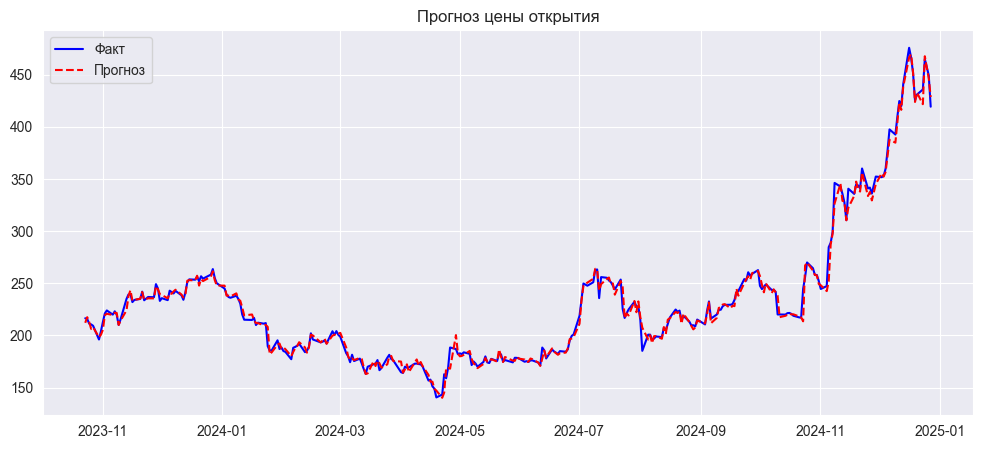

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test.index, y_test_price, label='Факт', color='blue')
plt.plot(test.index, y_pred_price, label='Прогноз', color='red', linestyle='--')
plt.legend()
plt.title('Прогноз цены открытия')
plt.show()

Вот какой код я использовал для оценки признаков:

In [23]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

# Выделяю из train валидационную выборку для ранней остановки
val_size = int(len(X_train) * 0.2)
X_train_final = X_train.iloc[:-val_size]
y_train_final = y_train.iloc[:-val_size]
X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]

# параметры XGBoost из головы
params = {
    'max_depth': 4,
    'learning_rate': 0.05,
    'random_state': 42
}

# dmatrix  для xgboost
dtrain = xgb.DMatrix(X_train_final, label=y_train_final)
dval = xgb.DMatrix(X_val, label=y_val)

# обучение с ранней остановкой
evals = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(
    params, dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=100,
)

[0]	train-rmse:0.03996	val-rmse:0.03428
[1]	train-rmse:0.03894	val-rmse:0.03349
[2]	train-rmse:0.03798	val-rmse:0.03276
[3]	train-rmse:0.03709	val-rmse:0.03208
[4]	train-rmse:0.03626	val-rmse:0.03147
[5]	train-rmse:0.03548	val-rmse:0.03092
[6]	train-rmse:0.03476	val-rmse:0.03038
[7]	train-rmse:0.03409	val-rmse:0.02992
[8]	train-rmse:0.03346	val-rmse:0.02952
[9]	train-rmse:0.03289	val-rmse:0.02907
[10]	train-rmse:0.03235	val-rmse:0.02869
[11]	train-rmse:0.03183	val-rmse:0.02835
[12]	train-rmse:0.03137	val-rmse:0.02804
[13]	train-rmse:0.03094	val-rmse:0.02774
[14]	train-rmse:0.03052	val-rmse:0.02750
[15]	train-rmse:0.03015	val-rmse:0.02727
[16]	train-rmse:0.02978	val-rmse:0.02709
[17]	train-rmse:0.02942	val-rmse:0.02690
[18]	train-rmse:0.02910	val-rmse:0.02673
[19]	train-rmse:0.02880	val-rmse:0.02653
[20]	train-rmse:0.02851	val-rmse:0.02637
[21]	train-rmse:0.02824	val-rmse:0.02620
[22]	train-rmse:0.02797	val-rmse:0.02605
[23]	train-rmse:0.02772	val-rmse:0.02588
[24]	train-rmse:0.02751	va

Попробуем со всеми признаками, а потом попробуем вырезать топ-3 или топ-5 самых маловлиятельных признаков и снова посмотрим на результаты.

In [24]:
# Получаю важность признаков 
# 'gain' - показывает вклад в снижение ошибки, 
# 'weight' - количество деревьев, где используется признак
importance = model.get_score(importance_type='gain')
weight = model.get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False)
weights_df = pd.DataFrame({
    'feature': list(weight.keys()),
    'weight': list(weight.values())
}).sort_values('weight', ascending=False)

print(importance_df)
print(f'\n\n')
print(weights_df)

         feature  importance
5         Return    0.013944
6           MA_5    0.002351
2            Low    0.002292
7  Volatility_10    0.002090
8     Close_lag1    0.002080
1           High    0.002049
4         Volume    0.002024
3          Close    0.001605
0           Open    0.001564



         feature  weight
0           Open   471.0
5         Return   366.0
4         Volume   251.0
6           MA_5   169.0
8     Close_lag1   162.0
7  Volatility_10   161.0
3          Close   133.0
1           High   116.0
2            Low    98.0
